**Setup**

In [2]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
!pip install -q kaggle statsmodels dagshub mlflow==2.22.0
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d data/
!unzip -o data/train.csv.zip -d data/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import dagshub

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

dagshub.init(repo_owner='aleko-mamukashvili', repo_name='Store-Sales-Forecasting', mlflow=True)
mlflow.set_experiment("ARIMA_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=5f6319c0-03f9-4dc7-8462-518dcc0bdde5&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=ee899e462dcdc6ccc47b34041ecd9d066df9863587c4445267fc9959155e8d4e




Accessing as aleko-mamukashvili

Initialized MLflow to track repo "aleko-mamukashvili/Store-Sales-Forecasting"

Repository aleko-mamukashvili/Store-Sales-Forecasting initialized!

<Experiment: artifact_location='mlflow-artifacts:/98980ff8f59b484eb7091a37c1199519', creation_time=1783800128493, experiment_id='4', last_update_time=1783800128493, lifecycle_stage='active', name='ARIMA_Training', tags={}>

In [4]:
train = pd.read_csv('data/train.csv')
train['Date'] = pd.to_datetime(train['Date'])

volume_by_pair = train.groupby(['Store', 'Dept'])['Weekly_Sales'].sum().sort_values(ascending=False)
print(volume_by_pair.head(5))

EXAMPLE_1 = volume_by_pair.index[0]
EXAMPLE_2 = (20, 30)

print("\nმაგალითი 1 (Store, Dept):", EXAMPLE_1)
print("მაგალითი 2 (Store, Dept):", EXAMPLE_2)

Store  Dept
14     92      26101497.71
2      92      23572153.03
20     92      23542625.04
13     92      23170876.20
4      92      22789210.43
Name: Weekly_Sales, dtype: float64

მაგალითი 1 (Store, Dept): (np.int64(14), np.int64(92))
მაგალითი 2 (Store, Dept): (20, 30)


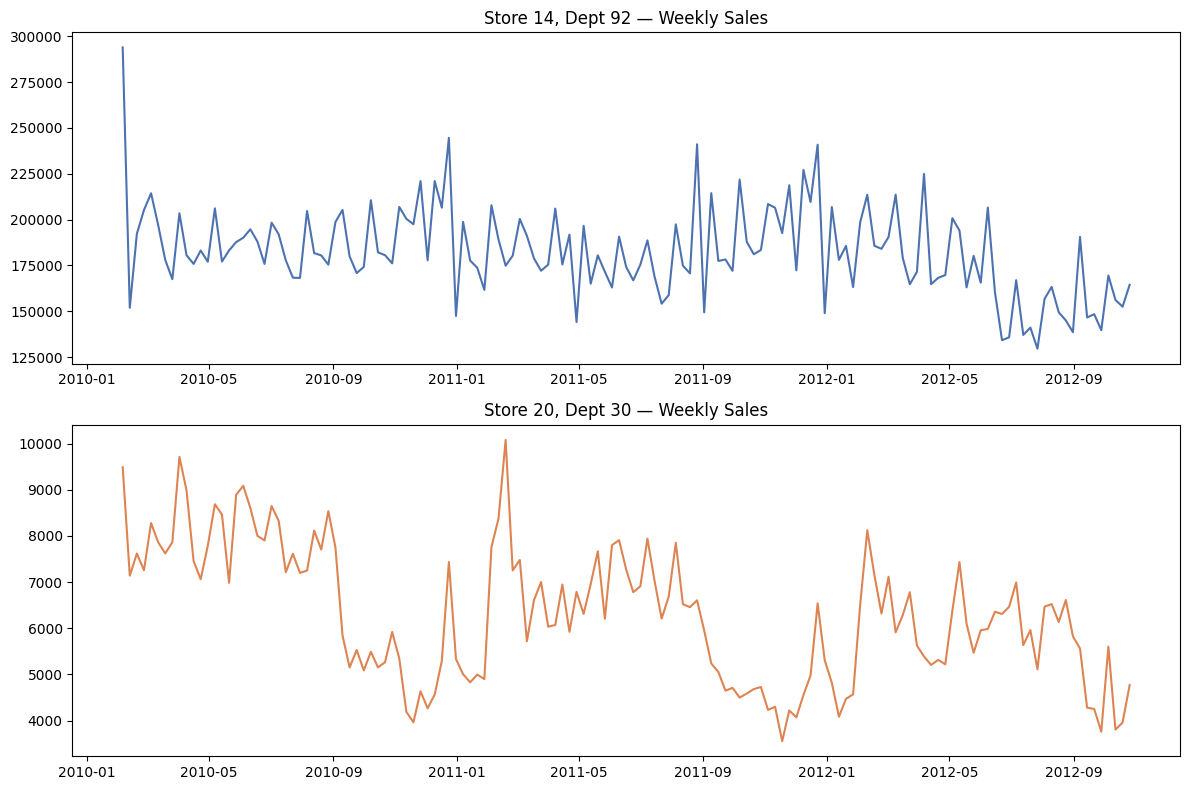

In [5]:
def get_series(store, dept):
    s = train[(train['Store'] == store) & (train['Dept'] == dept)].sort_values('Date')
    return s.set_index('Date')['Weekly_Sales']

series_1 = get_series(*EXAMPLE_1)
series_2 = get_series(*EXAMPLE_2)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(series_1.index, series_1.values, color='#4C72B0')
axes[0].set_title(f'Store {EXAMPLE_1[0]}, Dept {EXAMPLE_1[1]} — Weekly Sales')
axes[1].plot(series_2.index, series_2.values, color='#DD8452')
axes[1].set_title(f'Store {EXAMPLE_2[0]}, Dept {EXAMPLE_2[1]} — Weekly Sales')
plt.tight_layout()
plt.show()


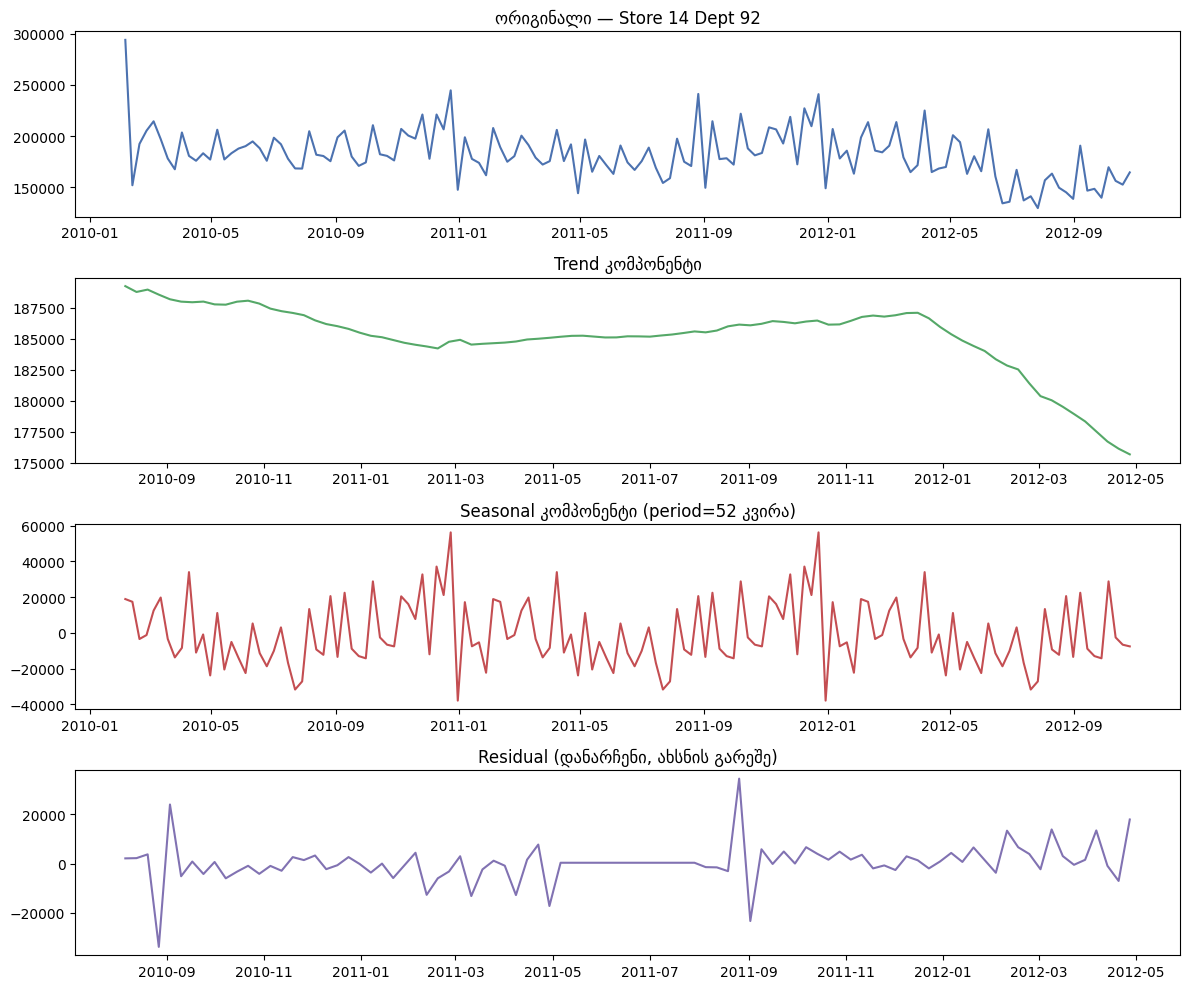

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(series_1, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
axes[0].plot(series_1.index, series_1.values, color='#4C72B0')
axes[0].set_title(f'ორიგინალი — Store {EXAMPLE_1[0]} Dept {EXAMPLE_1[1]}')
axes[1].plot(decomposition.trend.index, decomposition.trend.values, color='#55A868')
axes[1].set_title('Trend კომპონენტი')
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, color='#C44E52')
axes[2].set_title('Seasonal კომპონენტი (period=52 კვირა)')
axes[3].plot(decomposition.resid.index, decomposition.resid.values, color='#8172B2')
axes[3].set_title('Residual (დანარჩენი, ახსნის გარეშე)')
plt.tight_layout()
plt.show()


**ADF TEST**

In [6]:
def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f"--- {label} ---")
    print(f"ADF Statistic: {result[0]:.3f} | p-value: {result[1]:.4f}")
    is_stationary = result[1] < 0.05
    print(f"სტაციონარულია? {'დიახ' if is_stationary else 'არა — საჭიროა მეტი დიფერენცირება'}\n")
    return is_stationary

with mlflow.start_run(run_name="ARIMA_StationarityCheck"):
    stat_0 = adf_report(series_1, f'Store {EXAMPLE_1[0]} Dept {EXAMPLE_1[1]} (d=0, ორიგინალი)')
    stat_1 = adf_report(series_1.diff(), f'Store {EXAMPLE_1[0]} Dept {EXAMPLE_1[1]} (d=1)')
    mlflow.log_params({
        'series': str(EXAMPLE_1),
        'stationary_d0': stat_0,
        'stationary_d1': stat_1,
    })


--- Store 14 Dept 92 (d=0, ორიგინალი) ---
ADF Statistic: -1.192 | p-value: 0.6770
სტაციონარულია? ❌ არა — საჭიროა მეტი დიფერენცირება

--- Store 14 Dept 92 (d=1) ---
ADF Statistic: -4.867 | p-value: 0.0000
სტაციონარულია? ✅ დიახ

🏃 View run ARIMA_StationarityCheck at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/4/runs/6d151dce36d0433ead67b5b82c9abe9a
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/4


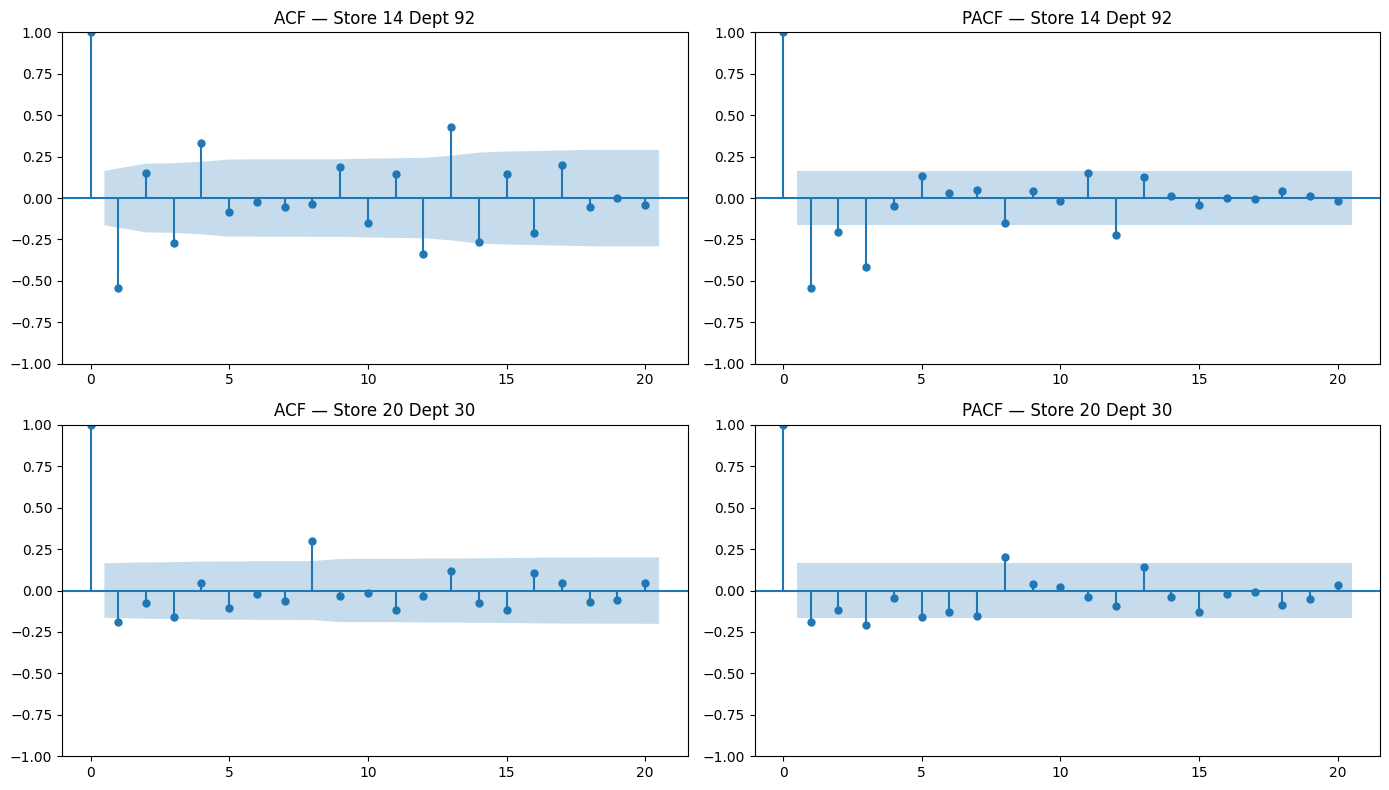

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(series_1.diff().dropna(), ax=axes[0,0], lags=20)
axes[0,0].set_title(f'ACF — Store {EXAMPLE_1[0]} Dept {EXAMPLE_1[1]}')
plot_pacf(series_1.diff().dropna(), ax=axes[0,1], lags=20)
axes[0,1].set_title(f'PACF — Store {EXAMPLE_1[0]} Dept {EXAMPLE_1[1]}')

plot_acf(series_2.diff().dropna(), ax=axes[1,0], lags=20)
axes[1,0].set_title(f'ACF — Store {EXAMPLE_2[0]} Dept {EXAMPLE_2[1]}')
plot_pacf(series_2.diff().dropna(), ax=axes[1,1], lags=20)
axes[1,1].set_title(f'PACF — Store {EXAMPLE_2[0]} Dept {EXAMPLE_2[1]}')

plt.tight_layout()
plt.show()


In [8]:
def train_test_split_series(series, test_weeks=20):
    return series.iloc[:-test_weeks], series.iloc[-test_weeks:]

def fit_arima_and_eval(series, label, order):
    train_part, test_part = train_test_split_series(series)
    model = ARIMA(train_part, order=order)
    fitted = model.fit()
    forecast = fitted.forecast(steps=len(test_part))
    mae = mean_absolute_error(test_part, forecast)
    aic = fitted.aic
    return fitted, forecast, test_part, mae, aic

In [11]:
candidate_orders = [(1,1,0), (1,1,1), (2,1,1), (2,1,2)]

results_1 = []
with mlflow.start_run(run_name=f"ARIMA_OrderSearch_Store{EXAMPLE_1[0]}_Dept{EXAMPLE_1[1]}"):
    for order in candidate_orders:
        try:
            fitted, forecast, test_part, mae, aic = fit_arima_and_eval(series_1, 'series_1', order)
            print(f"ARIMA{order}: MAE={mae:.2f} | AIC={aic:.1f}")
            results_1.append((order, mae, aic, fitted, forecast, test_part))
            mlflow.log_metric(f'mae_order_{order}', mae)
        except Exception as e:
            print(f"ARIMA{order}: ვერ დაფიტდა — {e}")

best_1 = min(results_1, key=lambda r: r[1])
print(f"\n საუკეთესო კონფიგურაცია (Store {EXAMPLE_1[0]} Dept {EXAMPLE_1[1]}): ARIMA{best_1[0]}, MAE={best_1[1]:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


ARIMA(1, 1, 0): MAE=40853.56 | AIC=2807.6
ARIMA(1, 1, 0): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  

ARIMA(1, 1, 1): MAE=32418.60 | AIC=2773.8
ARIMA(1, 1, 1): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(2, 1, 1): MAE=32971.15 | AIC=2776.0
ARIMA(2, 1, 1): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


ARIMA(2, 1, 2): MAE=33029.17 | AIC=2776.5
ARIMA(2, 1, 2): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}
🏃 View run ARIMA_OrderSearch_Store14_Dept92 at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/4/runs/322f160e0bc74dc48bd229156e3c9591
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/4

 საუკეთესო კონფიგურაცია (Store 14 Dept 92): ARIMA(1, 1, 1), MAE=32418.60


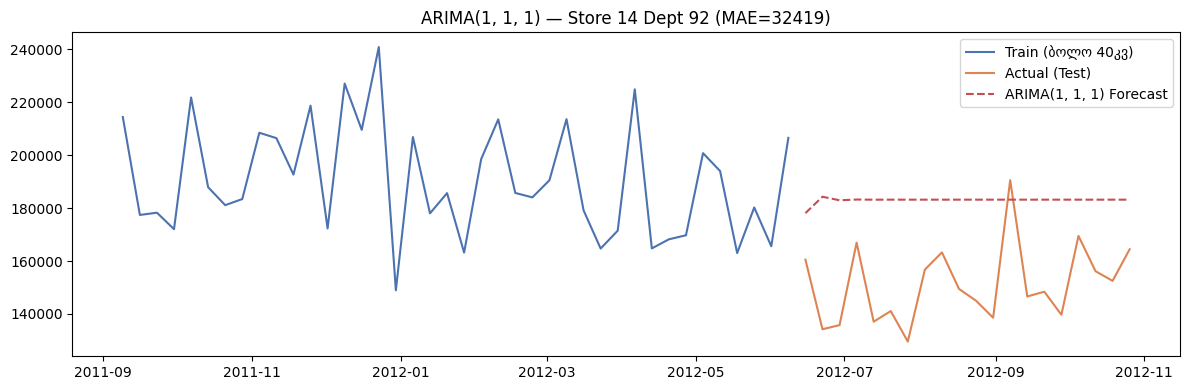

In [12]:
best_order_1, best_mae_1, best_aic_1, best_fitted_1, best_forecast_1, test_part_1 = best_1

fig, ax = plt.subplots(figsize=(12, 4))
train_part_1, _ = train_test_split_series(series_1)
ax.plot(train_part_1.index[-40:], train_part_1.values[-40:], label='Train (ბოლო 40კვ)', color='#4C72B0')
ax.plot(test_part_1.index, test_part_1.values, label='Actual (Test)', color='#DD8452')
ax.plot(test_part_1.index, best_forecast_1, '--', label=f'ARIMA{best_order_1} Forecast', color='#C44E52')
ax.set_title(f'ARIMA{best_order_1} — Store {EXAMPLE_1[0]} Dept {EXAMPLE_1[1]} (MAE={best_mae_1:.0f})')
ax.legend()
plt.tight_layout()
plt.show()


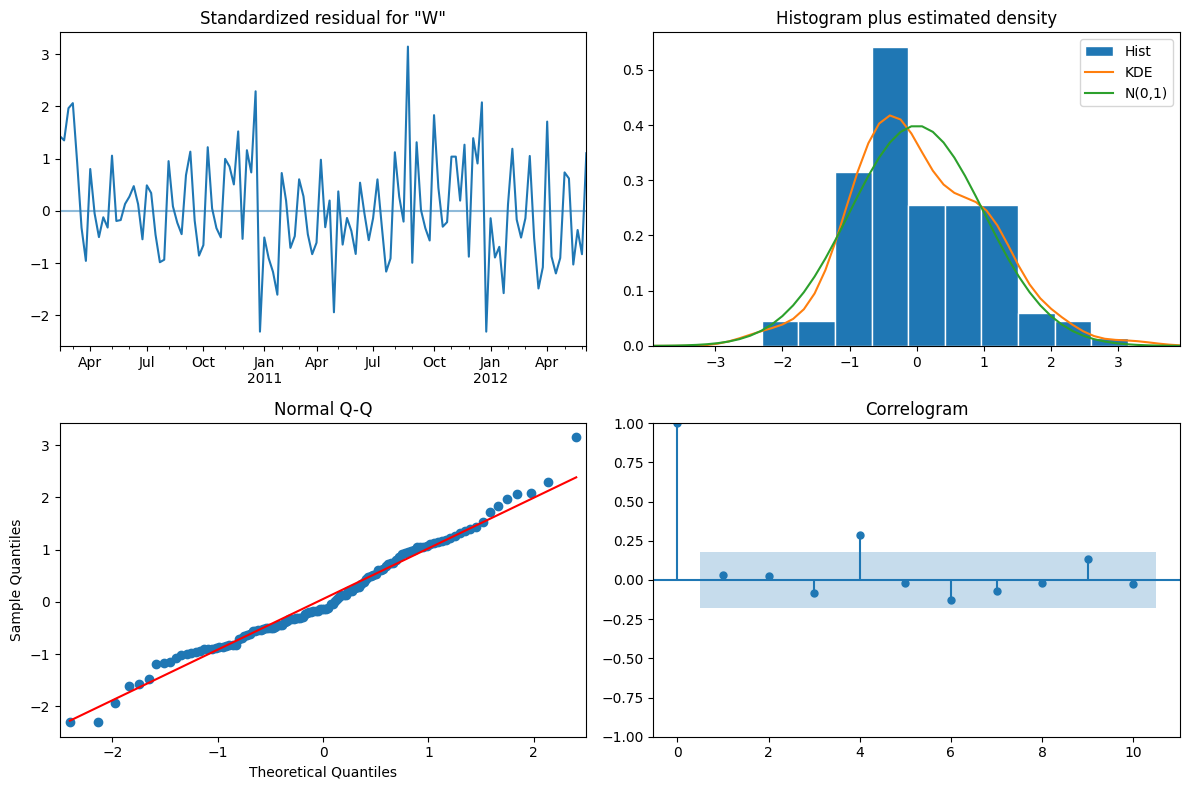

In [14]:
fig = best_fitted_1.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()



In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test_1 = acorr_ljungbox(best_fitted_1.resid, lags=[10, 20], return_df=True)
print(f"Ljung-Box ტესტი — Store {EXAMPLE_1[0]} Dept {EXAMPLE_1[1]}:")
print(lb_test_1)
print()
print("H0: residual-ებში აღარ არის ავტოკორელაცია (ანუ მოდელმა 'ყველაფერი დაიჭირა')")
if (lb_test_1['lb_pvalue'] > 0.05).all():
    print(" p-value > 0.05 ყველა lag-ზე — H0 არ უარვყავით, residual-ები თეთრი ხმაურის მსგავსია")
else:
    print(" p-value < 0.05 ზოგ lag-ზე — residual-ებში ჯერ კიდევ დარჩა აუხსნელი სტრუქტურა (სავარაუდოდ სეზონურობა)")

Ljung-Box ტესტი — Store 14 Dept 92:
      lb_stat  lb_pvalue
10   9.431876   0.491665
20  14.558970   0.801063

H0: residual-ებში აღარ არის ავტოკორელაცია (ანუ მოდელმა 'ყველაფერი დაიჭირა')
✅ p-value > 0.05 ყველა lag-ზე — H0 არ უარვყავით, residual-ები თეთრი ხმაურის მსგავსია


In [16]:
results_2 = []
with mlflow.start_run(run_name=f"ARIMA_OrderSearch_Store{EXAMPLE_2[0]}_Dept{EXAMPLE_2[1]}"):
    for order in candidate_orders:
        try:
            fitted, forecast, test_part, mae, aic = fit_arima_and_eval(series_2, 'series_2', order)
            print(f"ARIMA{order}: MAE={mae:.2f} | AIC={aic:.1f}")
            results_2.append((order, mae, aic, fitted, forecast, test_part))
            mlflow.log_metric(f'mae_order_{order}', mae)
        except Exception as e:
            print(f"ARIMA{order}: ვერ დაფიტდა — {e}")

best_2 = min(results_2, key=lambda r: r[1])
print(f"\n საუკეთესო კონფიგურაცია (Store {EXAMPLE_2[0]} Dept {EXAMPLE_2[1]}): ARIMA{best_2[0]}, MAE={best_2[1]:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


ARIMA(1, 1, 0): MAE=863.36 | AIC=2013.7
ARIMA(1, 1, 0): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters 

ARIMA(1, 1, 1): MAE=863.97 | AIC=2007.0
ARIMA(1, 1, 1): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters 

ARIMA(2, 1, 1): MAE=864.05 | AIC=2008.9
ARIMA(2, 1, 1): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters 

ARIMA(2, 1, 2): MAE=835.56 | AIC=2006.8
ARIMA(2, 1, 2): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}
🏃 View run ARIMA_OrderSearch_Store20_Dept30 at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/4/runs/a269c0a6c090414ea656e9261e12f784
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/4

✅ საუკეთესო კონფიგურაცია (Store 20 Dept 30): ARIMA(2, 1, 2), MAE=835.56


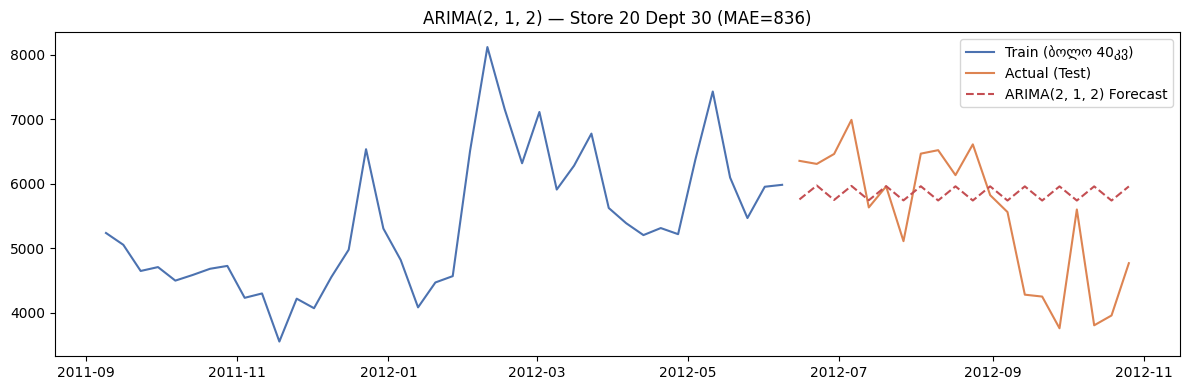

In [17]:
best_order_2, best_mae_2, best_aic_2, best_fitted_2, best_forecast_2, test_part_2 = best_2

fig, ax = plt.subplots(figsize=(12, 4))
train_part_2, _ = train_test_split_series(series_2)
ax.plot(train_part_2.index[-40:], train_part_2.values[-40:], label='Train (ბოლო 40კვ)', color='#4C72B0')
ax.plot(test_part_2.index, test_part_2.values, label='Actual (Test)', color='#DD8452')
ax.plot(test_part_2.index, best_forecast_2, '--', label=f'ARIMA{best_order_2} Forecast', color='#C44E52')
ax.set_title(f'ARIMA{best_order_2} — Store {EXAMPLE_2[0]} Dept {EXAMPLE_2[1]} (MAE={best_mae_2:.0f})')
ax.legend()
plt.tight_layout()
plt.show()

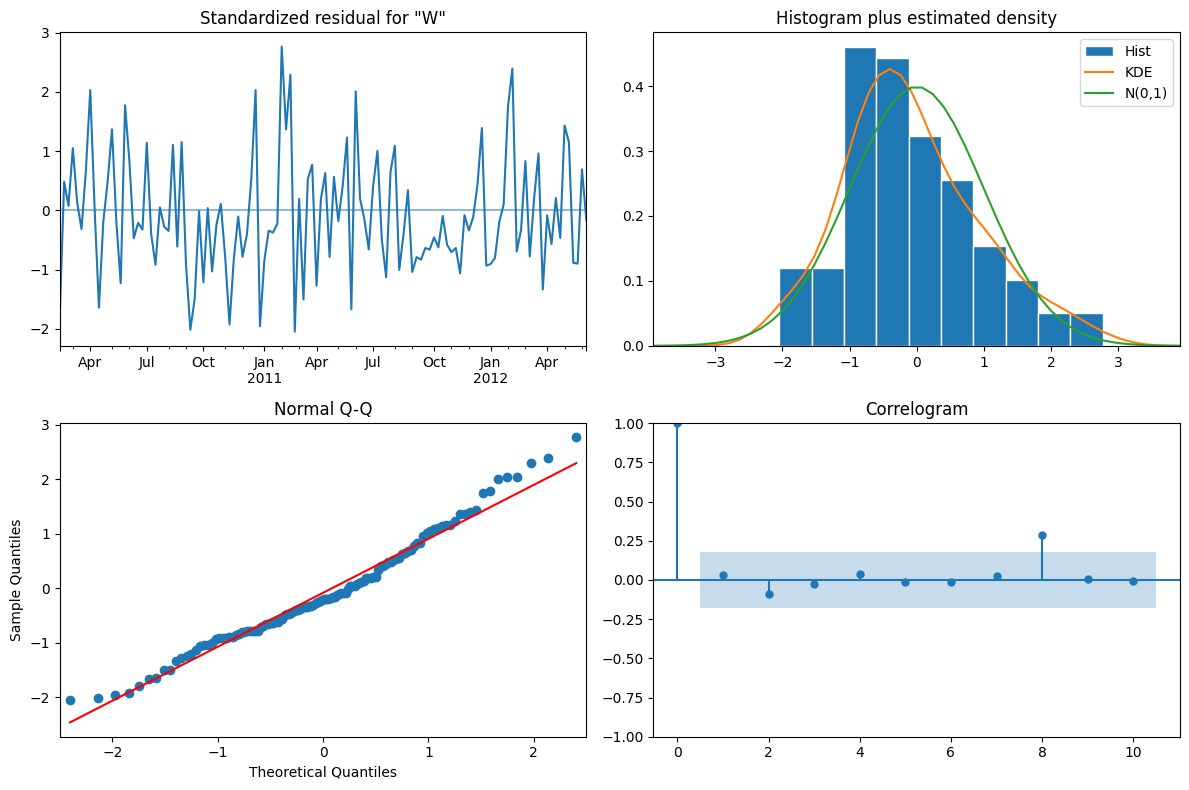

In [18]:
fig = best_fitted_2.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [19]:
lb_test_2 = acorr_ljungbox(best_fitted_2.resid, lags=[10, 20], return_df=True)
print(f"Ljung-Box ტესტი — Store {EXAMPLE_2[0]} Dept {EXAMPLE_2[1]}:")
print(lb_test_2)
if (lb_test_2['lb_pvalue'] > 0.05).all():
    print(" residual-ები თეთრი ხმაურის მსგავსია")
else:
    print(" residual-ებში დარჩა სტრუქტურა")

Ljung-Box ტესტი — Store 20 Dept 30:
      lb_stat  lb_pvalue
10  10.318137   0.413039
20  19.755198   0.473334
✅ residual-ები თეთრი ხმაურის მსგავსია


In [20]:
def seasonal_naive_forecast(series, test_weeks=20, season=52):
    train_part, test_part = train_test_split_series(series, test_weeks)
    naive_preds = []
    for date in test_part.index:
        lookup_date = date - pd.Timedelta(weeks=season)
        naive_preds.append(series.get(lookup_date, train_part.mean()))
    mae_naive = mean_absolute_error(test_part, naive_preds)
    return mae_naive

naive_mae_1 = seasonal_naive_forecast(series_1)
naive_mae_2 = seasonal_naive_forecast(series_2)

comparison = pd.DataFrame({
    'Series': [f'Store{EXAMPLE_1[0]}_Dept{EXAMPLE_1[1]}', f'Store{EXAMPLE_2[0]}_Dept{EXAMPLE_2[1]}'],
    'ARIMA_MAE': [best_mae_1, best_mae_2],
    'SeasonalNaive_MAE': [naive_mae_1, naive_mae_2],
})
comparison['ARIMA_better?'] = comparison['ARIMA_MAE'] < comparison['SeasonalNaive_MAE']
print(comparison)

with mlflow.start_run(run_name="ARIMA_vs_SeasonalNaive"):
    mlflow.log_metrics({
        'naive_mae_series1': naive_mae_1,
        'naive_mae_series2': naive_mae_2,
        'arima_mae_series1': best_mae_1,
        'arima_mae_series2': best_mae_2,
    })

           Series     ARIMA_MAE  SeasonalNaive_MAE  ARIMA_better?
0  Store14_Dept92  32418.599060         30538.6020          False
1  Store20_Dept30    835.555954           647.0475          False
🏃 View run ARIMA_vs_SeasonalNaive at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/4/runs/af68a25afe9b4eeaa9085ab08874b51a
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/4


In [21]:
np.random.seed(42)
all_pairs = train.groupby(['Store', 'Dept']).size()
# მხოლოდ საკმარისი ისტორიის მქონე სერიები (მინიმუმ 100 კვირა)
eligible_pairs = all_pairs[all_pairs >= 100].index.tolist()
random_pairs = [eligible_pairs[i] for i in np.random.choice(len(eligible_pairs), size=8, replace=False)]

robustness_results = []
with mlflow.start_run(run_name="ARIMA_RobustnessCheck_8RandomSeries"):
    for store, dept in random_pairs:
        s = get_series(store, dept)
        if len(s) < 60:
            continue
        try:
            best_local_mae = None
            for order in [(1,1,0), (1,1,1), (2,1,1)]:
                try:
                    _, _, _, mae, _ = fit_arima_and_eval(s, f'{store}_{dept}', order)
                    if best_local_mae is None or mae < best_local_mae:
                        best_local_mae = mae
                except Exception:
                    continue
            naive_mae = seasonal_naive_forecast(s)
            robustness_results.append({
                'Store': store, 'Dept': dept,
                'ARIMA_MAE': best_local_mae, 'Naive_MAE': naive_mae,
                'ARIMA_better': best_local_mae < naive_mae if best_local_mae else None,
            })
            print(f"Store {store} Dept {dept}: ARIMA={best_local_mae:.1f} | Naive={naive_mae:.1f}")
        except Exception as e:
            print(f"Store {store} Dept {dept}: გამოტოვებულია — {e}")

    robustness_df = pd.DataFrame(robustness_results)
    win_rate = robustness_df['ARIMA_better'].mean()
    mlflow.log_metric('arima_win_rate_vs_naive', win_rate)
    mlflow.log_metric('mean_arima_mae', robustness_df['ARIMA_MAE'].mean())
    mlflow.log_metric('mean_naive_mae', robustness_df['Naive_MAE'].mean())

print(f"\n ARIMA სჯობს Naive-ს {win_rate*100:.0f}% შემთხვევაში ({len(robustness_df)} სერიიდან)")
robustness_df

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

Store 7 Dept 98: ARIMA=102.6 | Naive=145.7


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  

Store 22 Dept 33: ARIMA=1316.7 | Naive=988.0


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  

...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  

Store 17 Dept 60: ARIMA=113.7 | Naive=121.9


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  

Store 34 Dept 74: ARIMA=628.9 | Naive=589.8
🏃 View run ARIMA_RobustnessCheck_8RandomSeries at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/4/runs/6eb254d6feea4baca4de35269e9be3f6
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/4

📊 ARIMA სჯობს Naive-ს 38% შემთხვევაში (8 სერიიდან)


,Store,Dept,ARIMA_MAE,Naive_MAE,ARIMA_better
0,7,98,102.586946,145.7085,True
1,22,33,1316.650142,988.0280,False
2,37,3,493.365060,432.7690,False
3,24,50,193.525592,419.4000,True
4,17,16,21053.125708,2092.5530,False
5,19,44,703.757855,387.7430,False
6,17,60,113.702033,121.8700,True
7,34,74,628.945057,589.7950,False


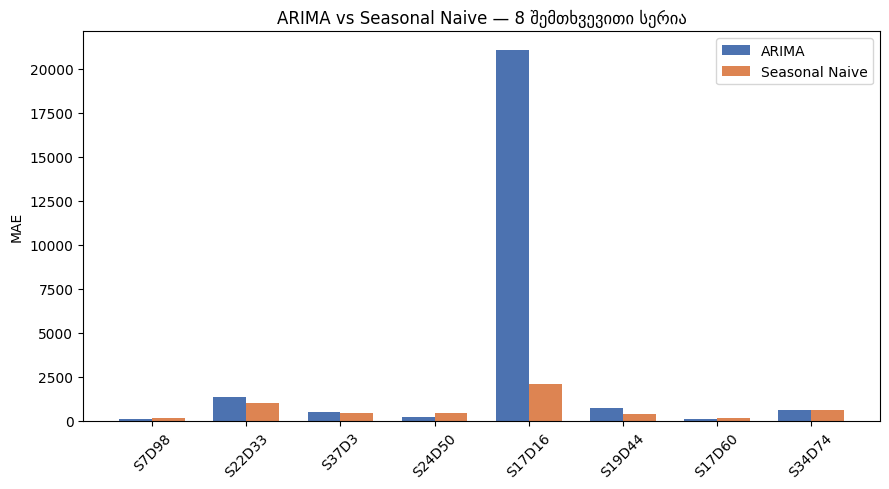

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(robustness_df))
width = 0.35
ax.bar(x - width/2, robustness_df['ARIMA_MAE'], width, label='ARIMA', color='#4C72B0')
ax.bar(x + width/2, robustness_df['Naive_MAE'], width, label='Seasonal Naive', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels([f"S{r.Store}D{r.Dept}" for r in robustness_df.itertuples()], rotation=45)
ax.set_ylabel('MAE')
ax.set_title('ARIMA vs Seasonal Naive — 8 შემთხვევითი სერია')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
with mlflow.start_run(run_name="ARIMA_Final_BestPerSeries"):
    mlflow.log_params({
        'best_order_series1': str(best_order_1),
        'best_order_series2': str(best_order_2),
    })
    mlflow.log_metrics({
        'mae_series1': best_mae_1,
        'mae_series2': best_mae_2,
        'aic_series1': best_aic_1,
        'aic_series2': best_aic_2,
    })
    print(" ARIMA შედეგები ჩაილოგა MLflow-ში")

✅ ARIMA შედეგები ჩაილოგა MLflow-ში
🏃 View run ARIMA_Final_BestPerSeries at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/4/runs/4837d0524d834464b9aa58075e560c28
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/4
